<a href="https://colab.research.google.com/github/ashfaq20071234-droid/HEART-ATTACK_PREDICTION/blob/main/HEART_ATTACK_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROBLEM STATEMENT
With HadHeartAttack as the prediction variable, the task would involve using other features in the dataset to predict whether a patient has experienced a heart attack. This could be approached as a binary classification problem, where the model learns patterns from the other variables to predict the likelihood of HadHeartAttack (0 for no, 1 for yes).


Heart disease is one of the leading causes of mortality worldwide, with heart attacks being a primary manifestation. Early detection and intervention can significantly reduce the risk and improve patient outcomes. In this project, we aim to develop a predictive model that leverages patient demographic, health, and lifestyle information to determine the likelihood of a heart attack occurrence. By analyzing this data, healthcare providers may gain insights into high-risk patients, enabling proactive measures and better allocation of medical resources.

The objective is to predict whether a patient has had a heart attack (binary outcome: HadHeartAttack) based on a range of features, including medical history, lifestyle habits, and demographic details. This model could serve as an assistive tool in clinical decision-making and help in implementing preventive healthcare strategies.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df=pd.read_csv("/content/Patients Data ( Used for Heart Disease Prediction ) (12).csv", encoding='latin1')
df

,ÿPatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,Fair,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,Never used e-cigarettes in my entire life,1,"White only, Non-Hispanic",0,0,0,1,"No, did not receive any tetanus shot in the pa...",0,1
1,2,Alabama,Female,Very good,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received Tdap",0,0
2,3,Alabama,Male,Excellent,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",1,0,0,0,"Yes, received tetanus shot but not sure what type",0,0
3,4,Alabama,Male,Very good,Age 70 to 74,1.78,95.250000,30.129999,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received tetanus shot but not sure what type",0,0
4,5,Alabama,Female,Good,Age 50 to 54,1.68,78.019997,27.760000,0,0,...,Never used e-cigarettes in my entire life,1,"Black only, Non-Hispanic",0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237625,237626,Puerto Rico,Female,Good,Age 60 to 64,1.57,90.720001,36.580002,0,0,...,Not at all (right now),0,Hispanic,0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
237626,237627,Puerto Rico,Female,Good,Age 55 to 59,1.70,72.570000,25.059999,0,1,...,Not at all (right now),0,Hispanic,0,1,0,0,"Yes, received Tdap",0,0
237627,237628,Puerto Rico,Male,Fair,Age 45 to 49,1.75,70.309998,22.889999,1,1,...,Not at all (right now),1,Hispanic,0,1,1,1,"Yes, received Tdap",1,0
237628,237629,Puerto Rico,Female,Very good,Age 25 to 29,1.57,46.720001,18.840000,0,0,...,Never used e-cigarettes in my entire life,0,Hispanic,0,1,0,0,"No, did not receive any tetanus shot in the pa...",0,1


In [ ]:
df.head()

,ÿPatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,Fair,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,Never used e-cigarettes in my entire life,1,"White only, Non-Hispanic",0,0,0,1,"No, did not receive any tetanus shot in the pa...",0,1
1,2,Alabama,Female,Very good,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received Tdap",0,0
2,3,Alabama,Male,Excellent,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",1,0,0,0,"Yes, received tetanus shot but not sure what type",0,0
3,4,Alabama,Male,Very good,Age 70 to 74,1.78,95.250000,30.129999,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received tetanus shot but not sure what type",0,0
4,5,Alabama,Female,Good,Age 50 to 54,1.68,78.019997,27.760000,0,0,...,Never used e-cigarettes in my entire life,1,"Black only, Non-Hispanic",0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ÿPatientID                 237630 non-null  int64  
 1   State                      237630 non-null  object 
 2   Sex                        237630 non-null  object 
 3   GeneralHealth              237630 non-null  object 
 4   AgeCategory                237630 non-null  object 
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

In [ ]:
df.isnull().sum()

,0
ÿPatientID,0
State,0
Sex,0
GeneralHealth,0
AgeCategory,0
HeightInMeters,0
WeightInKilograms,0
BMI,0
HadHeartAttack,0
HadAngina,0


In [ ]:
df.duplicated().sum()

np.int64(0)

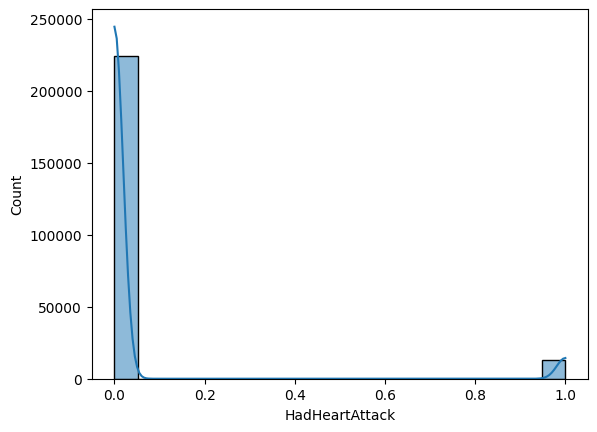

In [ ]:
sns.histplot(df["HadHeartAttack"],kde=True)
plt.show()

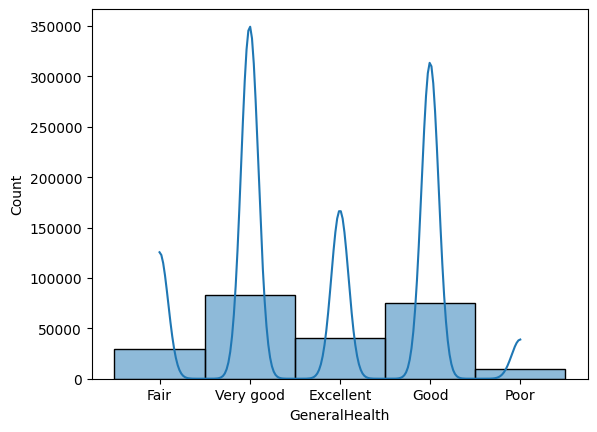

In [ ]:
sns.histplot(df['GeneralHealth'], kde=True)
plt.show()

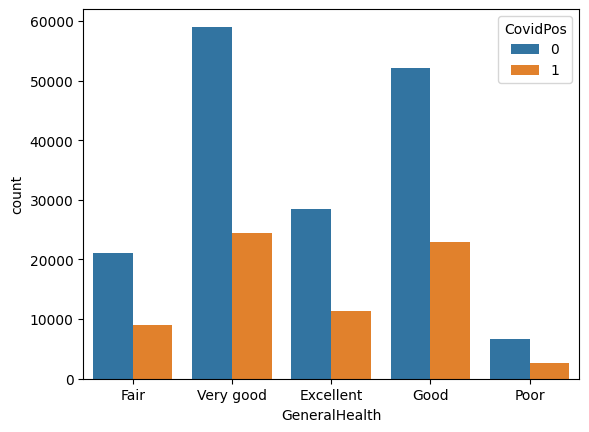

In [ ]:
sns.countplot(data=df, x='GeneralHealth', hue='CovidPos')
plt.show()

In [ ]:
df.head()

,ÿPatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,Fair,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,Never used e-cigarettes in my entire life,1,"White only, Non-Hispanic",0,0,0,1,"No, did not receive any tetanus shot in the pa...",0,1
1,2,Alabama,Female,Very good,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received Tdap",0,0
2,3,Alabama,Male,Excellent,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",1,0,0,0,"Yes, received tetanus shot but not sure what type",0,0
3,4,Alabama,Male,Very good,Age 70 to 74,1.78,95.250000,30.129999,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received tetanus shot but not sure what type",0,0
4,5,Alabama,Female,Good,Age 50 to 54,1.68,78.019997,27.760000,0,0,...,Never used e-cigarettes in my entire life,1,"Black only, Non-Hispanic",0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ÿPatientID                 237630 non-null  int64  
 1   State                      237630 non-null  object 
 2   Sex                        237630 non-null  object 
 3   GeneralHealth              237630 non-null  object 
 4   AgeCategory                237630 non-null  object 
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

In [ ]:
df

,ÿPatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,Fair,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,Never used e-cigarettes in my entire life,1,"White only, Non-Hispanic",0,0,0,1,"No, did not receive any tetanus shot in the pa...",0,1
1,2,Alabama,Female,Very good,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received Tdap",0,0
2,3,Alabama,Male,Excellent,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",1,0,0,0,"Yes, received tetanus shot but not sure what type",0,0
3,4,Alabama,Male,Very good,Age 70 to 74,1.78,95.250000,30.129999,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received tetanus shot but not sure what type",0,0
4,5,Alabama,Female,Good,Age 50 to 54,1.68,78.019997,27.760000,0,0,...,Never used e-cigarettes in my entire life,1,"Black only, Non-Hispanic",0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237625,237626,Puerto Rico,Female,Good,Age 60 to 64,1.57,90.720001,36.580002,0,0,...,Not at all (right now),0,Hispanic,0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
237626,237627,Puerto Rico,Female,Good,Age 55 to 59,1.70,72.570000,25.059999,0,1,...,Not at all (right now),0,Hispanic,0,1,0,0,"Yes, received Tdap",0,0
237627,237628,Puerto Rico,Male,Fair,Age 45 to 49,1.75,70.309998,22.889999,1,1,...,Not at all (right now),1,Hispanic,0,1,1,1,"Yes, received Tdap",1,0
237628,237629,Puerto Rico,Female,Very good,Age 25 to 29,1.57,46.720001,18.840000,0,0,...,Never used e-cigarettes in my entire life,0,Hispanic,0,1,0,0,"No, did not receive any tetanus shot in the pa...",0,1


In [ ]:
df["State"].unique

<bound method Series.unique of 0             Alabama
1             Alabama
2             Alabama
3             Alabama
4             Alabama
             ...     
237625    Puerto Rico
237626    Puerto Rico
237627    Puerto Rico
237628    Puerto Rico
237629    Puerto Rico
Name: State, Length: 237630, dtype: object>

In [ ]:
df['State'].replace( ["Alabama","Alaska","Arizona","Arkansas","California","Colorado","Connecticut","Delaware","District of Columbia", "Florida","Georgia","Guam","Hawaii","Idaho","Illinois","Indiana","Iowa","Kansas","Kentucky","Louisiana", "Maine","Maryland","Massachusetts","Michigan","Minnesota","Mississippi","Missouri","Montana","Nebraska", "Nevada","New Hampshire","New Jersey","New Mexico","New York","North Carolina","North Dakota","Ohio", "Oklahoma","Oregon","Pennsylvania","Puerto Rico","Rhode Island","South Carolina","South Dakota", "Tennessee","Texas","Utah","Vermont","Virginia","Virgin Islands","Washington","West Virginia", "Wisconsin","Wyoming"], [1,2,3,4,5,6,7,8,9, 10,11,12,13,14,15,16,17,18,19,20, 21,22,23,24,25,26,27,28,29, 30,31,32,33,34,35,36,37, 38,39,40,41,42,43,44, 45,46,47,48,49,50,51,52, 53,54], inplace=True )

/tmp/ipykernel_486/2696272888.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['State'].replace( ["Alabama","Alaska","Arizona","Arkansas","California","Colorado","Connecticut","Delaware","District of Columbia", "Florida","Georgia","Guam","Hawaii","Idaho","Illinois","Indiana","Iowa","Kansas","Kentucky","Louisiana", "Maine","Maryland","Massachusetts","Michigan","Minnesota","Mississippi","Missouri","Montana","Nebraska", "Nevada","New Hampshire","New Jersey","New Mexico","New York","North Carolina","North Dakota","Ohio", "Oklahoma","Oregon","Pennsylvania","Puerto Rico","Rhode Island","South Carolina","South Dakota", "Tennessee","Texas","Utah","Vermont","Virginia","Virgin Islands","Washington","West Virginia", "Wisconsin","Wyoming"], [1,2,3,4,5,6,7,8,9, 10,

In [ ]:
df["Sex"].unique

<bound method Series.unique of 0         Female
1         Female
2           Male
3           Male
4         Female
           ...  
237625    Female
237626    Female
237627      Male
237628    Female
237629    Female
Name: Sex, Length: 237630, dtype: object>

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['State'] = le.fit_transform(df['State'])
df['Sex'] = le.fit_transform(df['Sex'])
df['RaceEthnicityCategory'] = le.fit_transform(df['RaceEthnicityCategory'])
df['HadDiabetes'] = le.fit_transform(df['HadDiabetes'])
df['SmokerStatus'] = le.fit_transform(df['SmokerStatus'])
df['TetanusLast10Tdap'] = le.fit_transform(df['TetanusLast10Tdap'])


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ÿPatientID                 237630 non-null  int64  
 1   State                      237630 non-null  int64  
 2   Sex                        237630 non-null  int64  
 3   GeneralHealth              237630 non-null  object 
 4   AgeCategory                237630 non-null  object 
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

In [ ]:
df['AgeCategory'].replace(['Age 75 to 79', 'Age 65 to 69', 'Age 60 to 64', 'Age 70 to 74', 'Age 50 to 54', 'Age 80 or older', 'Age 55 to 59', 'Age 25 to 29', 'Age 40 to 44', 'Age 30 to 34', 'Age 35 to 39', 'Age 18 to 24', 'Age 45 to 49'],[77,67,62,72,52,85,57,27,42,32,37,21,47],inplace=True)

/tmp/ipykernel_486/4233404005.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['AgeCategory'].replace(['Age 75 to 79', 'Age 65 to 69', 'Age 60 to 64', 'Age 70 to 74', 'Age 50 to 54', 'Age 80 or older', 'Age 55 to 59', 'Age 25 to 29', 'Age 40 to 44', 'Age 30 to 34', 'Age 35 to 39', 'Age 18 to 24', 'Age 45 to 49'],[77,67,62,72,52,85,57,27,42,32,37,21,47],inplace=True)
/tmp/ipykernel_486/4233404005.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old

In [ ]:
df['ECigaretteUsage'].replace(['Never used e-cigarettes in my entire life', 'Not at all (right now)', 'Use them every day', 'Use them some days'],[1,2,3,4],inplace=True)

/tmp/ipykernel_486/2556276798.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ECigaretteUsage'].replace(['Never used e-cigarettes in my entire life', 'Not at all (right now)', 'Use them every day', 'Use them some days'],[1,2,3,4],inplace=True)
/tmp/ipykernel_486/2556276798.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future

In [ ]:
df["GeneralHealth"].replace(['Excellent', 'Fair', 'Good', 'Poor', 'Very good'],[1,2,3,4,5],inplace=True)

/tmp/ipykernel_486/2110630635.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["GeneralHealth"].replace(['Excellent', 'Fair', 'Good', 'Poor', 'Very good'],[1,2,3,4,5],inplace=True)
/tmp/ipykernel_486/2110630635.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["GeneralHealth"].replace(['E

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ÿPatientID                 237630 non-null  int64  
 1   State                      237630 non-null  int64  
 2   Sex                        237630 non-null  int64  
 3   GeneralHealth              237630 non-null  int64  
 4   AgeCategory                237630 non-null  int64  
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

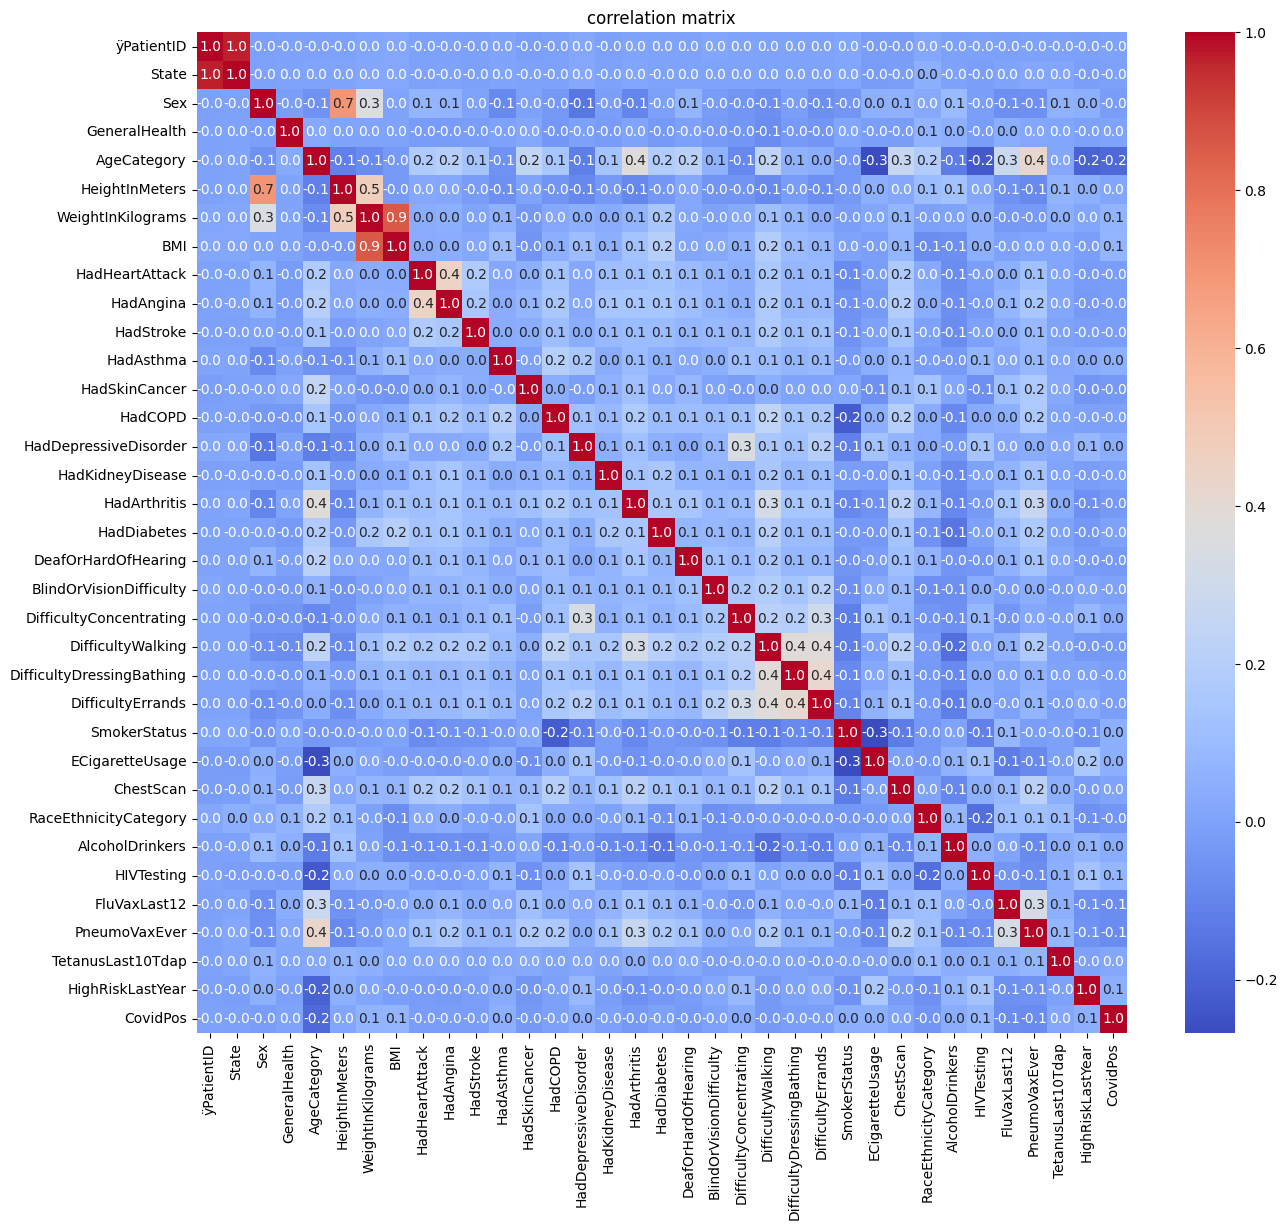

In [ ]:
plt.figure (figsize=(15,13))
corr_matrix = df.corr()
sns.heatmap(corr_matrix,annot=True, fmt='0.01f' , cmap='coolwarm')
plt.title('correlation matrix')
plt.show()

In [ ]:
df.drop(["State","WeightInKilograms","BMI"],axis=1,inplace=True)

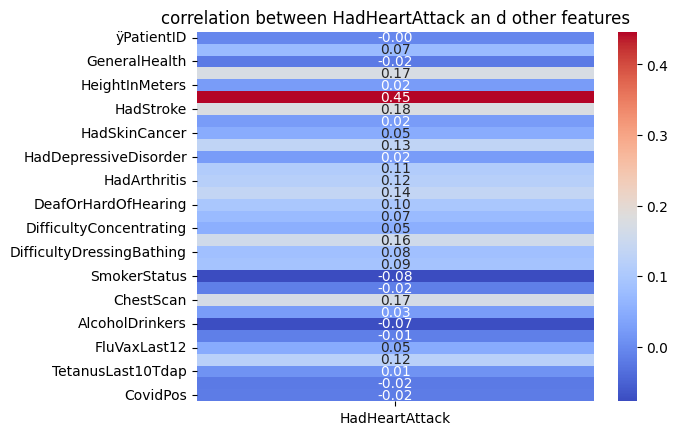

In [ ]:
HadHeartAttack_corr = df.corr()['HadHeartAttack']
HadHeartAttack_corr = HadHeartAttack_corr.drop('HadHeartAttack')

sns.heatmap(HadHeartAttack_corr.to_frame(), annot=True, fmt='.2f',cmap='coolwarm',cbar=True, annot_kws={'size':10})
plt.title('correlation between HadHeartAttack an d other features')
plt.show()

In [ ]:
df.drop(["ÿPatientID","Sex","GeneralHealth","HeightInMeters","HadAsthma","HadSkinCancer","HadDepressiveDisorder","BlindOrVisionDifficulty","DifficultyConcentrating","DifficultyDressingBathing","DifficultyErrands","SmokerStatus","ECigaretteUsage","RaceEthnicityCategory","AlcoholDrinkers","HIVTesting","FluVaxLast12","TetanusLast10Tdap","HighRiskLastYear","CovidPos"],axis=1,inplace=True)

<Axes: >

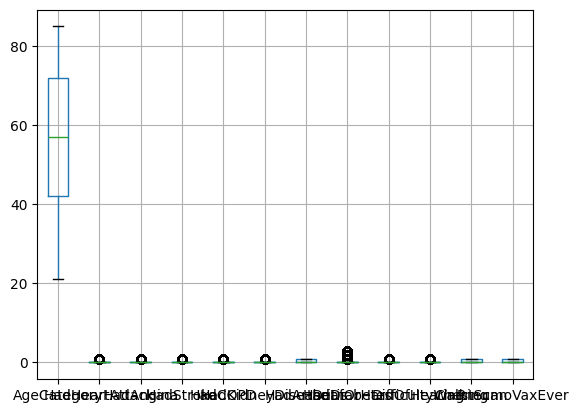

In [ ]:
df.boxplot()

In [ ]:
def remove_outliers_iqr(df, exclude_column):
  for col in df.columns:
    if col == exclude_column:
      continue
      Q1 = df[col.quantile(0.25)]
      Q3 = df[col].quantile(0.75)
      IQR = Q3 - Q1
      lower_bound = Q1 - 1.5 * IQR
      upper_bound = Q3 + 1.5 * IQR
      df = df[(df[col] >= lower_bount) & (df[col] <= upper_bound)]
  return df


df_cleaned = remove_outliers_iqr(df, exclude_column='HadHeartAttack')
df=df_cleaned

In [ ]:
df.shape

(237630, 12)

In [ ]:
df

,AgeCategory,HadHeartAttack,HadAngina,HadStroke,HadCOPD,HadKidneyDisease,HadArthritis,HadDiabetes,DeafOrHardOfHearing,DifficultyWalking,ChestScan,PneumoVaxEver
0,77,0,1,0,0,0,1,2,0,1,1,1
1,67,0,0,0,0,0,1,0,0,0,0,1
2,62,0,0,0,0,0,0,0,0,0,0,0
3,72,0,0,0,0,0,1,2,0,0,0,1
4,52,0,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
237625,62,0,0,0,0,1,0,2,0,0,0,0
237626,57,0,1,0,0,0,1,0,0,0,0,0
237627,47,1,1,0,0,0,1,0,0,1,1,1
237628,27,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.head()

,AgeCategory,HadHeartAttack,HadAngina,HadStroke,HadCOPD,HadKidneyDisease,HadArthritis,HadDiabetes,DeafOrHardOfHearing,DifficultyWalking,ChestScan,PneumoVaxEver
0,77,0,1,0,0,0,1,2,0,1,1,1
1,67,0,0,0,0,0,1,0,0,0,0,1
2,62,0,0,0,0,0,0,0,0,0,0,0
3,72,0,0,0,0,0,1,2,0,0,0,1
4,52,0,0,0,0,0,0,0,0,0,1,0


In [ ]:
df.shape

(237630, 12)

In [ ]:
df

,AgeCategory,HadHeartAttack,HadAngina,HadStroke,HadCOPD,HadKidneyDisease,HadArthritis,HadDiabetes,DeafOrHardOfHearing,DifficultyWalking,ChestScan,PneumoVaxEver
0,77,0,1,0,0,0,1,2,0,1,1,1
1,67,0,0,0,0,0,1,0,0,0,0,1
2,62,0,0,0,0,0,0,0,0,0,0,0
3,72,0,0,0,0,0,1,2,0,0,0,1
4,52,0,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
237625,62,0,0,0,0,1,0,2,0,0,0,0
237626,57,0,1,0,0,0,1,0,0,0,0,0
237627,47,1,1,0,0,0,1,0,0,1,1,1
237628,27,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

features = ['AgeCategory', 'HadAngina','HadStroke', 'HadCOPD', 'HadKidneyDisease', 'HadArthritis', 'HadDiabetes', 'DeafOrHardOfHearing', 'DifficultyWalking', 'ChestScan', 'PneumoVaxEver']

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df[features])
scaled_df = pd.DataFrame(scaled_data, columns=features)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

X = df[['AgeCategory', 'HadAngina','HadStroke', 'HadCOPD', 'HadKidneyDisease', 'HadArthritis', 'HadDiabetes', 'DeafOrHardOfHearing', 'DifficultyWalking', 'ChestScan', 'PneumoVaxEver']]
y = df['HadHeartAttack']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')





Baseline model accuracy: 0.94
